# 第十九章：咖啡自動機與不可逆性

## The Coffee Automaton - PyTorch 實作

**論文**: Scott Aaronson, Sean M. Carroll, Lauren Ouellette (2014) - "Quantifying the Rise and Fall of Complexity in Closed Systems: The Coffee Automaton"

**arXiv**: https://arxiv.org/abs/1405.6903

> **與第一章的關係**：本章與第一章「複雜動力學第一定律」同為 Scott Aaronson 的作品，且都以咖啡混合為例。但兩章側重點不同：第一章探討「複雜度為何先升後降」，本章則深入剖析「不可逆性的物理與計算基礎」——包括 Landauer 原理、Maxwell 妖精、計算不可逆性等第一章未涵蓋的主題。

本 notebook 實作咖啡自動機論文中的核心概念：
1. 擴散過程與熵增加
2. 相空間與 Liouville 定理
3. Poincaré 回歸
4. Maxwell 妖精與 Landauer 原理
5. 計算不可逆性
6. 資訊瓶頸與神經網路

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
from scipy.stats import entropy as scipy_entropy
from typing import Tuple, List, Dict
from dataclasses import dataclass
import hashlib

# 設定隨機種子
np.random.seed(42)
torch.manual_seed(42)

# 設定繪圖風格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# 檢查設備
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用設備: {device}")
print(f"PyTorch 版本: {torch.__version__}")
print(f"NumPy 版本: {np.__version__}")

使用設備: cpu
PyTorch 版本: 2.9.1
NumPy 版本: 2.4.1


## 第一部分：擴散過程模擬

模擬牛奶在咖啡中的擴散過程。擴散方程：

$$\frac{\partial c}{\partial t} = D \nabla^2 c$$

這個過程是不可逆的：牛奶會混合，但不會自動分離。

模擬咖啡混合過程...


/var/folders/4z/9g413kps2l14p9j7pzv9kp8c0000gn/T/ipykernel_44056/2187720207.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


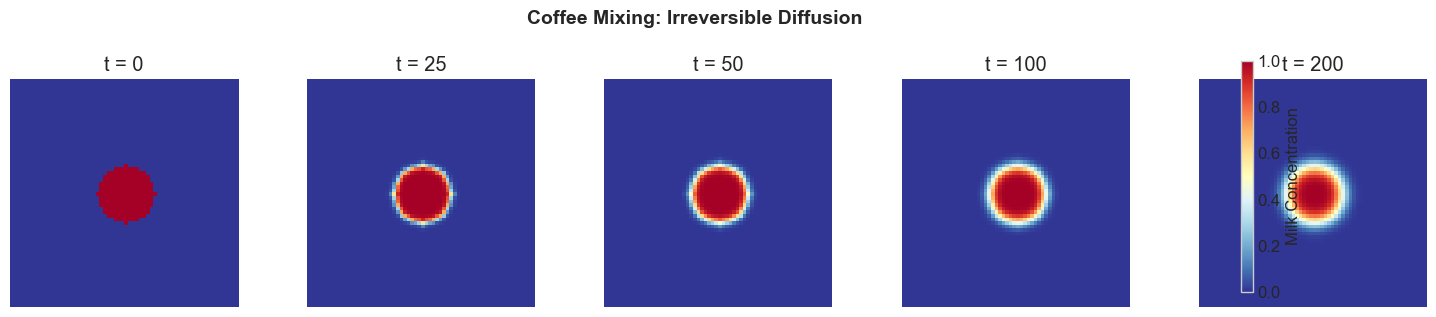


觀察：牛奶擴散開來，永遠不會自動分離回去！


In [2]:
class DiffusionSimulator:
    """擴散過程模擬器"""
    
    def __init__(self, size: int = 64, diffusion_coeff: float = 0.1):
        """
        初始化擴散模擬器
        
        Args:
            size: 網格大小
            diffusion_coeff: 擴散係數 D
        """
        self.size = size
        self.D = diffusion_coeff
        
        # Laplacian 核（離散化的 ∇²）
        self.laplacian_kernel = np.array([[0, 1, 0],
                                          [1, -4, 1],
                                          [0, 1, 0]])
    
    def initialize_coffee_cup(self) -> np.ndarray:
        """初始化咖啡杯，中央有一滴牛奶"""
        cup = np.zeros((self.size, self.size))
        center = self.size // 2
        radius = self.size // 8
        
        # 建立圓形牛奶滴
        y, x = np.ogrid[:self.size, :self.size]
        mask = (x - center)**2 + (y - center)**2 <= radius**2
        cup[mask] = 1.0
        
        return cup
    
    def diffusion_step(self, concentration: np.ndarray, dt: float = 0.1) -> np.ndarray:
        """執行一步擴散"""
        # 計算 Laplacian
        laplacian = convolve(concentration, self.laplacian_kernel, 
                            mode='constant', cval=0.0)
        
        # 更新濃度：c(t+Δt) = c(t) + D·Δt·∇²c
        new_concentration = concentration + self.D * dt * laplacian
        
        # 確保濃度在有效範圍內
        return np.clip(new_concentration, 0, 1)
    
    def simulate(self, num_steps: int = 200) -> List[np.ndarray]:
        """執行完整擴散模擬"""
        cup = self.initialize_coffee_cup()
        history = [cup.copy()]
        
        for _ in range(num_steps):
            cup = self.diffusion_step(cup)
            history.append(cup.copy())
        
        return history


# 執行擴散模擬
print("模擬咖啡混合過程...")
simulator = DiffusionSimulator(size=64, diffusion_coeff=0.1)
mixing_history = simulator.simulate(num_steps=200)

# 視覺化關鍵時刻
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
timesteps = [0, 25, 50, 100, 200]

for ax, t in zip(axes, timesteps):
    im = ax.imshow(mixing_history[t], cmap='RdYlBu_r', vmin=0, vmax=1)
    ax.set_title(f't = {t}')
    ax.axis('off')

plt.colorbar(im, ax=axes, label='Milk Concentration', fraction=0.046)
plt.suptitle('Coffee Mixing: Irreversible Diffusion', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('diffusion_process.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n觀察：牛奶擴散開來，永遠不會自動分離回去！")

## 第二部分：熵的計算與增長

**Shannon 熵**：$H = -\sum_i p_i \log_2 p_i$

**熱力學熵**：$S = k_B \ln \Omega$

熵量化了系統的「無序程度」。第二定律說熵只會增加。

計算熵隨時間的變化...


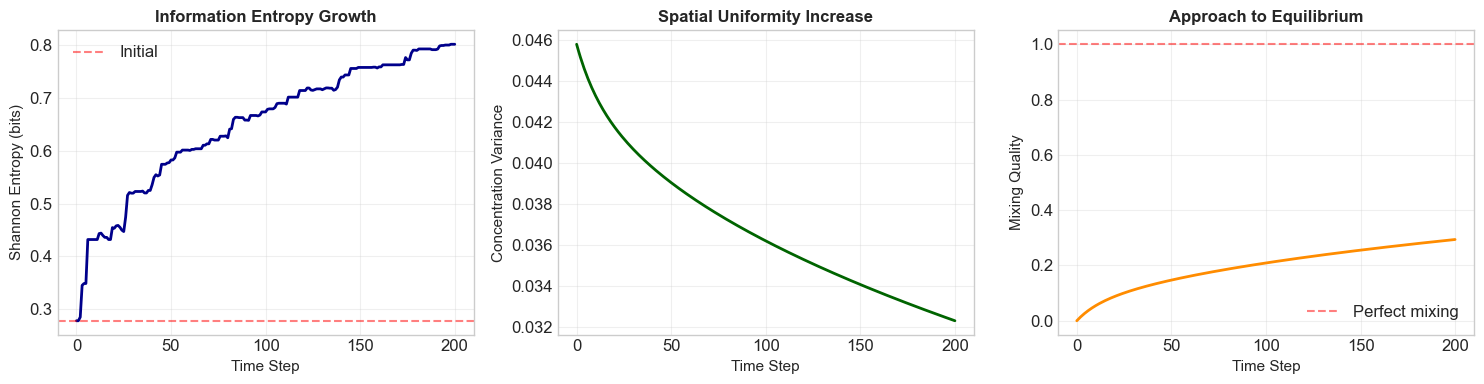


初始 Shannon 熵: 0.278 bits
最終 Shannon 熵: 0.801 bits
熵增加量: 0.523 bits
最終混合程度: 29.4%

關鍵洞見：熵單調增加——這就是熱力學第二定律！


In [3]:
def compute_shannon_entropy(concentration: np.ndarray, num_bins: int = 20) -> float:
    """
    計算濃度分布的 Shannon 熵
    
    Args:
        concentration: 濃度場
        num_bins: 直方圖的 bin 數量
    
    Returns:
        Shannon 熵（位元）
    """
    flat = concentration.flatten()
    hist, _ = np.histogram(flat, bins=num_bins, range=(0, 1), density=True)
    
    # 正規化為機率
    hist = hist / hist.sum()
    hist = hist[hist > 0]  # 移除零值避免 log(0)
    
    return -np.sum(hist * np.log2(hist))


def compute_mixing_quality(concentration: np.ndarray) -> float:
    """
    計算混合程度（0 = 完全分離，1 = 完全混合）
    """
    mean_conc = concentration.mean()
    variance = np.var(concentration)
    
    # 最大變異數（在這個平均值下）
    max_variance = mean_conc * (1 - mean_conc)
    
    if max_variance == 0:
        return 1.0
    
    return 1 - (variance / max_variance)


# 計算熵隨時間的變化
print("計算熵隨時間的變化...")

entropies = [compute_shannon_entropy(cup) for cup in mixing_history]
mixing_qualities = [compute_mixing_quality(cup) for cup in mixing_history]
variances = [np.var(cup) for cup in mixing_history]

# 繪製熵增長圖
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 圖 1：Shannon 熵
axes[0].plot(entropies, linewidth=2, color='darkblue')
axes[0].set_xlabel('Time Step', fontsize=11)
axes[0].set_ylabel('Shannon Entropy (bits)', fontsize=11)
axes[0].set_title('Information Entropy Growth', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=entropies[0], color='red', linestyle='--', alpha=0.5, label='Initial')
axes[0].legend()

# 圖 2：變異數（空間不均勻度）
axes[1].plot(variances, linewidth=2, color='darkgreen')
axes[1].set_xlabel('Time Step', fontsize=11)
axes[1].set_ylabel('Concentration Variance', fontsize=11)
axes[1].set_title('Spatial Uniformity Increase', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 圖 3：混合程度
axes[2].plot(mixing_qualities, linewidth=2, color='darkorange')
axes[2].set_xlabel('Time Step', fontsize=11)
axes[2].set_ylabel('Mixing Quality', fontsize=11)
axes[2].set_title('Approach to Equilibrium', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Perfect mixing')
axes[2].legend()

plt.tight_layout()
plt.savefig('entropy_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n初始 Shannon 熵: {entropies[0]:.3f} bits")
print(f"最終 Shannon 熵: {entropies[-1]:.3f} bits")
print(f"熵增加量: {entropies[-1] - entropies[0]:.3f} bits")
print(f"最終混合程度: {mixing_qualities[-1]:.1%}")
print("\n關鍵洞見：熵單調增加——這就是熱力學第二定律！")

## 第三部分：相空間與 Liouville 定理

**Liouville 定理**：哈密頓演化保持相空間體積不變。

$$\frac{d}{dt} \int_V d\Gamma = 0$$

但為什麼熵還會增加？答案是**粗粒化**：我們無法追蹤微觀細節。

模擬相空間演化與粗粒化...


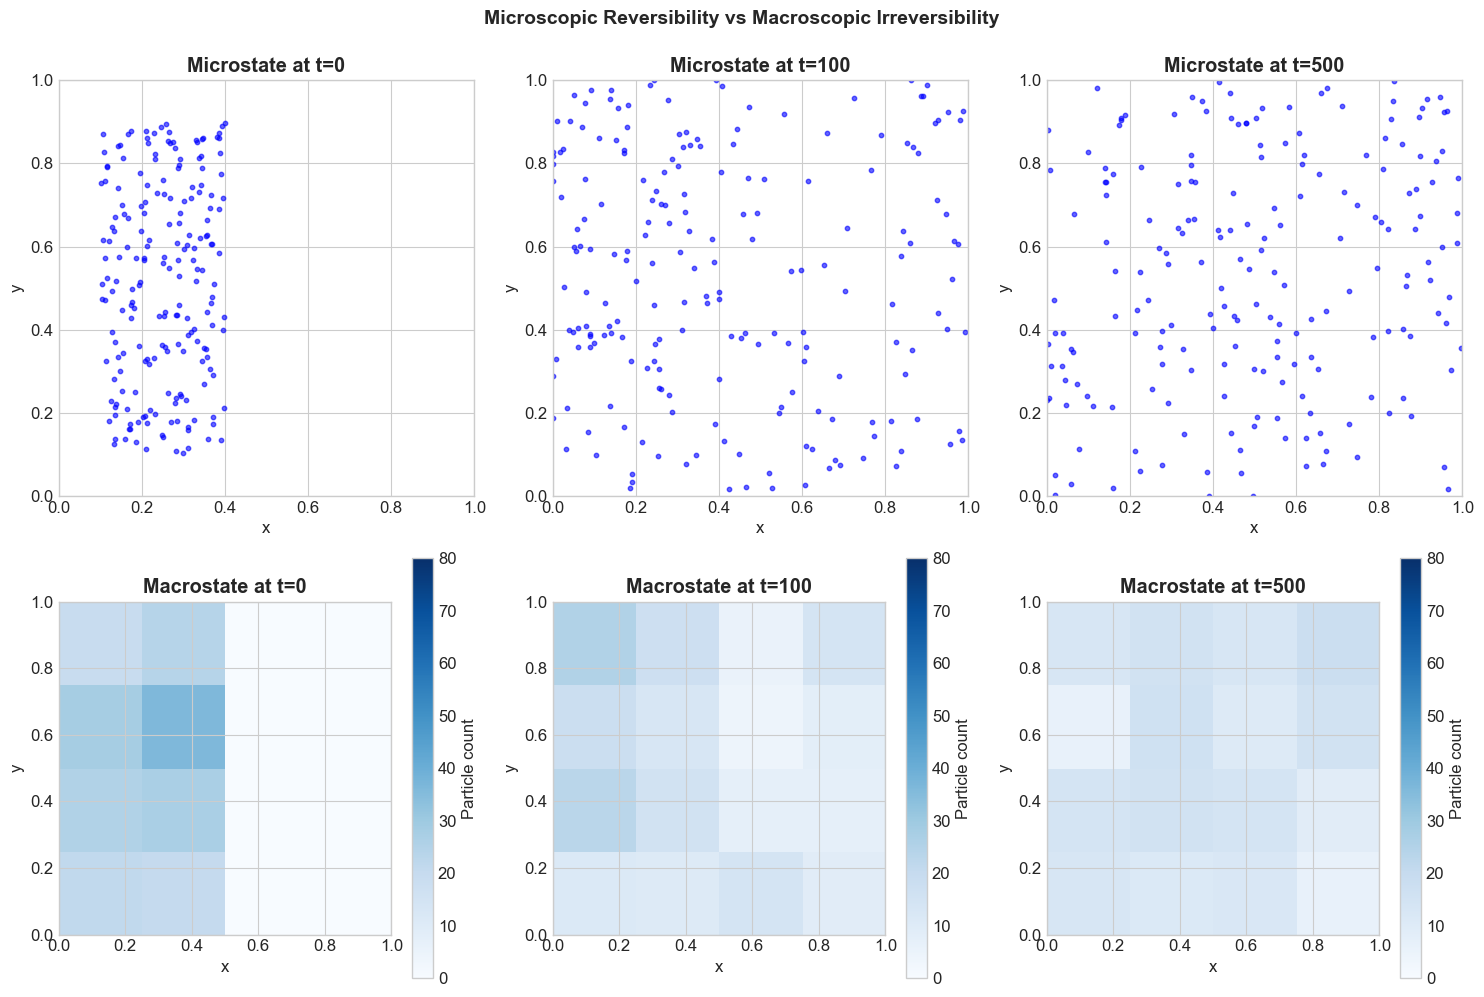

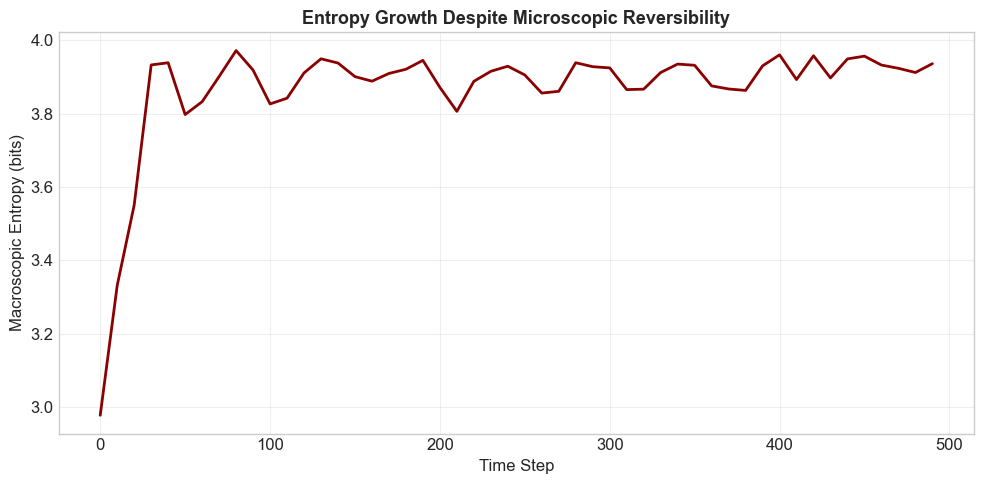


關鍵洞見：
  • Liouville 定理保證微觀可逆性
  • 但粗粒化後，巨觀熵仍然增加！
  • 許多微觀態 → 同一個巨觀態
  • 這就是不可逆性的來源


In [4]:
@dataclass
class Particle:
    """二維相空間中的粒子"""
    x: float
    y: float
    vx: float
    vy: float


class PhaseSpaceSimulator:
    """相空間模擬器，展示 Liouville 定理"""
    
    def __init__(self, num_particles: int = 200):
        self.num_particles = num_particles
        self.particles = self._initialize_particles()
    
    def _initialize_particles(self, region: str = 'left') -> List[Particle]:
        """初始化粒子在左半邊"""
        particles = []
        speed = 0.02
        
        for _ in range(self.num_particles):
            # 位置在左半邊
            x = np.random.uniform(0.1, 0.4)
            y = np.random.uniform(0.1, 0.9)
            
            # 隨機速度
            angle = np.random.uniform(0, 2*np.pi)
            vx = speed * np.cos(angle)
            vy = speed * np.sin(angle)
            
            particles.append(Particle(x, y, vx, vy))
        
        return particles
    
    def update(self, dt: float = 1.0):
        """更新粒子位置（自由運動 + 反射邊界）"""
        new_particles = []
        
        for p in self.particles:
            new_x = p.x + p.vx * dt
            new_y = p.y + p.vy * dt
            new_vx, new_vy = p.vx, p.vy
            
            # 反射邊界
            if new_x < 0 or new_x > 1:
                new_vx = -new_vx
                new_x = np.clip(new_x, 0, 1)
            if new_y < 0 or new_y > 1:
                new_vy = -new_vy
                new_y = np.clip(new_y, 0, 1)
            
            new_particles.append(Particle(new_x, new_y, new_vx, new_vy))
        
        self.particles = new_particles
    
    def compute_macrostate(self, num_bins: int = 4) -> np.ndarray:
        """粗粒化：將粒子分配到空間 bin 中"""
        positions = np.array([[p.x, p.y] for p in self.particles])
        hist, _, _ = np.histogram2d(positions[:, 0], positions[:, 1],
                                   bins=num_bins, range=[[0, 1], [0, 1]])
        return hist
    
    def compute_macrostate_entropy(self, macrostate: np.ndarray) -> float:
        """計算巨觀態的熵"""
        counts = macrostate.flatten()
        if counts.sum() == 0:
            return 0.0
        
        probs = counts / counts.sum()
        probs = probs[probs > 0]
        
        return -np.sum(probs * np.log2(probs))


# 執行相空間模擬
print("模擬相空間演化與粗粒化...")

phase_sim = PhaseSpaceSimulator(num_particles=200)
num_steps = 500

particle_history = [[Particle(p.x, p.y, p.vx, p.vy) for p in phase_sim.particles]]
macrostate_entropies = []

for step in range(num_steps):
    phase_sim.update()
    particle_history.append([Particle(p.x, p.y, p.vx, p.vy) for p in phase_sim.particles])
    
    if step % 10 == 0:
        macrostate = phase_sim.compute_macrostate()
        macrostate_entropies.append(phase_sim.compute_macrostate_entropy(macrostate))

# 視覺化
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 上排：微觀態（粒子位置）
timesteps_vis = [0, 100, 500]
for idx, t in enumerate(timesteps_vis):
    ax = axes[0, idx]
    ps = particle_history[t]
    positions = np.array([[p.x, p.y] for p in ps])
    ax.scatter(positions[:, 0], positions[:, 1], s=10, alpha=0.6, color='blue')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_title(f'Microstate at t={t}', fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

# 下排：巨觀態（粗粒化）
for idx, t in enumerate([0, 100, 500]):
    ax = axes[1, idx]
    ps = particle_history[t]
    positions = np.array([[p.x, p.y] for p in ps])
    hist, _, _ = np.histogram2d(positions[:, 0], positions[:, 1],
                               bins=4, range=[[0, 1], [0, 1]])
    im = ax.imshow(hist.T, cmap='Blues', origin='lower',
                  extent=[0, 1, 0, 1], vmin=0, vmax=80)
    ax.set_title(f'Macrostate at t={t}', fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, label='Particle count')

plt.suptitle('Microscopic Reversibility vs Macroscopic Irreversibility',
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('phase_space.png', dpi=150, bbox_inches='tight')
plt.show()

# 繪製巨觀熵增長
plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(macrostate_entropies)) * 10, macrostate_entropies,
         linewidth=2, color='darkred')
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Macroscopic Entropy (bits)', fontsize=12)
plt.title('Entropy Growth Despite Microscopic Reversibility', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('macroscopic_entropy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n關鍵洞見：")
print("  • Liouville 定理保證微觀可逆性")
print("  • 但粗粒化後，巨觀熵仍然增加！")
print("  • 許多微觀態 → 同一個巨觀態")
print("  • 這就是不可逆性的來源")

## 第四部分：Poincaré 回歸

**Poincaré 回歸定理**：有限相空間中的任何系統最終都會任意接近地返回初始狀態。

但回歸時間約為 $e^N$，對於咖啡杯（$N \sim 10^{23}$）約為 $10^{10^{23}}$ 秒——遠超宇宙年齡！

展示 Poincaré 回歸定理...

系統有 16 個狀態
初始狀態: 0
回歸發生在時間步: [8, 16, 24, 32, 40]...
回歸週期: 8 步


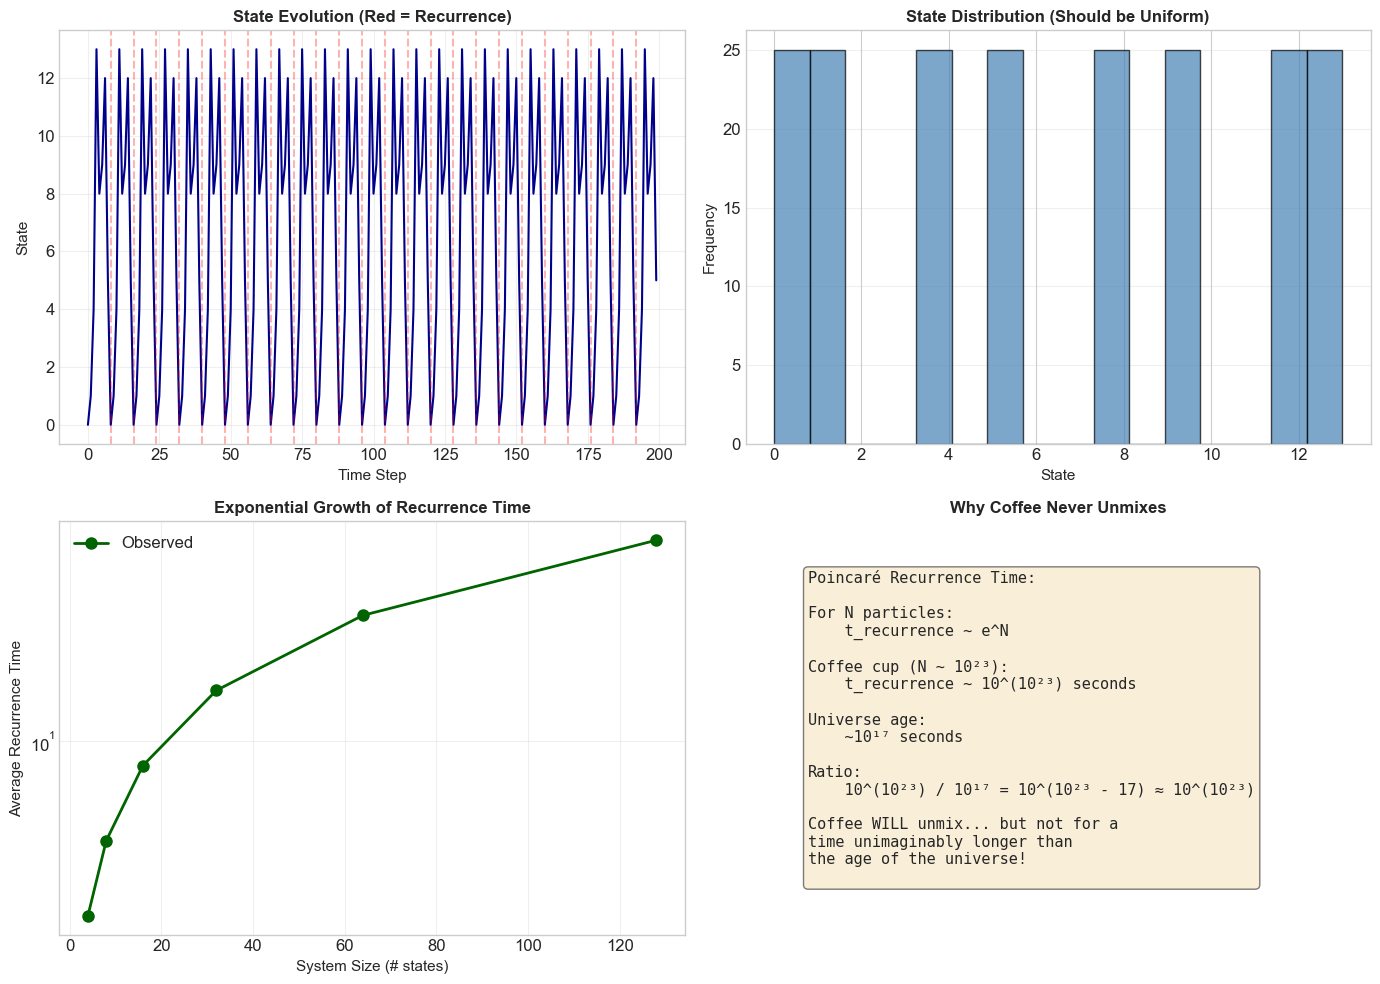


關鍵洞見：
  1. Poincaré 回歸確實會發生——有限系統最終會回歸
  2. 但回歸時間隨系統大小指數增長
  3. 對於咖啡（~10²³ 粒子）：回歸時間 ~ 10^(10²³) 秒
  4. 宇宙年齡：~10¹⁷ 秒
  5. 所以咖啡會分離...在等待宇宙年齡的 10^(10²³) 倍之後！


In [5]:
def simulate_poincare_recurrence(num_states: int = 16, num_steps: int = 10000) -> Tuple[List[int], List[int]]:
    """
    模擬簡單確定性系統的 Poincaré 回歸
    
    Args:
        num_states: 相空間大小
        num_steps: 模擬步數
    
    Returns:
        states: 訪問的狀態列表
        recurrence_times: 回歸時間列表
    """
    # 確定性演化規則：state_next = (a * state + b) mod num_states
    a, b = 3, 1
    
    initial_state = 0
    state = initial_state
    states = [state]
    recurrence_times = []
    
    for step in range(1, num_steps):
        state = (a * state + b) % num_states
        states.append(state)
        
        if state == initial_state:
            recurrence_times.append(step)
    
    return states, recurrence_times


def estimate_recurrence_time_scaling() -> Tuple[List[int], List[float]]:
    """估計回歸時間如何隨系統大小變化"""
    sizes = [4, 8, 16, 32, 64, 128]
    avg_recurrence_times = []
    
    for size in sizes:
        _, rec_times = simulate_poincare_recurrence(num_states=size, num_steps=size*20)
        if len(rec_times) > 0:
            avg_time = np.mean(np.diff([0] + rec_times))
        else:
            avg_time = size * 10
        avg_recurrence_times.append(avg_time)
    
    return sizes, avg_recurrence_times


# 展示 Poincaré 回歸
print("展示 Poincaré 回歸定理...")

num_states = 16
states, recurrence_times = simulate_poincare_recurrence(num_states=num_states, num_steps=200)

print(f"\n系統有 {num_states} 個狀態")
print(f"初始狀態: {states[0]}")
print(f"回歸發生在時間步: {recurrence_times[:5]}...")

if len(recurrence_times) > 1:
    period = recurrence_times[1] - recurrence_times[0]
    print(f"回歸週期: {period} 步")

# 視覺化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 圖 1：狀態軌跡
ax = axes[0, 0]
ax.plot(states[:200], linewidth=1.5, color='darkblue')
for rt in recurrence_times:
    if rt < 200:
        ax.axvline(rt, color='red', alpha=0.3, linestyle='--')
ax.set_xlabel('Time Step', fontsize=11)
ax.set_ylabel('State', fontsize=11)
ax.set_title('State Evolution (Red = Recurrence)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# 圖 2：狀態分布直方圖
ax = axes[0, 1]
ax.hist(states, bins=num_states, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('State Distribution (Should be Uniform)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 圖 3：回歸時間隨系統大小的變化
ax = axes[1, 0]
sizes, rec_times_avg = estimate_recurrence_time_scaling()
ax.semilogy(sizes, rec_times_avg, 'o-', linewidth=2, markersize=8, color='darkgreen', label='Observed')
ax.set_xlabel('System Size (# states)', fontsize=11)
ax.set_ylabel('Average Recurrence Time', fontsize=11)
ax.set_title('Exponential Growth of Recurrence Time', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 圖 4：為什麼咖啡永遠不會分離
ax = axes[1, 1]
ax.axis('off')
info_text = """Poincaré Recurrence Time:

For N particles:
    t_recurrence ~ e^N

Coffee cup (N ~ 10²³):
    t_recurrence ~ 10^(10²³) seconds

Universe age:
    ~10¹⁷ seconds

Ratio:
    10^(10²³) / 10¹⁷ = 10^(10²³ - 17) ≈ 10^(10²³)

Coffee WILL unmix... but not for a
time unimaginably longer than
the age of the universe!
"""
ax.text(0.1, 0.5, info_text, fontsize=11, verticalalignment='center',
       fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_title('Why Coffee Never Unmixes', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('poincare_recurrence.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n關鍵洞見：")
print("  1. Poincaré 回歸確實會發生——有限系統最終會回歸")
print("  2. 但回歸時間隨系統大小指數增長")
print("  3. 對於咖啡（~10²³ 粒子）：回歸時間 ~ 10^(10²³) 秒")
print("  4. 宇宙年齡：~10¹⁷ 秒")
print("  5. 所以咖啡會分離...在等待宇宙年齡的 10^(10²³) 倍之後！")

## 第五部分：Maxwell 妖精與 Landauer 原理

**Maxwell 妖精**：一個能分選快慢分子的「妖精」，似乎能違反第二定律。

**Landauer 原理**：擦除一個位元至少產生 $k_B T \ln 2$ 的熱量。

這解決了悖論：妖精必須擦除記憶，這會增加熵！

模擬 Maxwell 妖精...


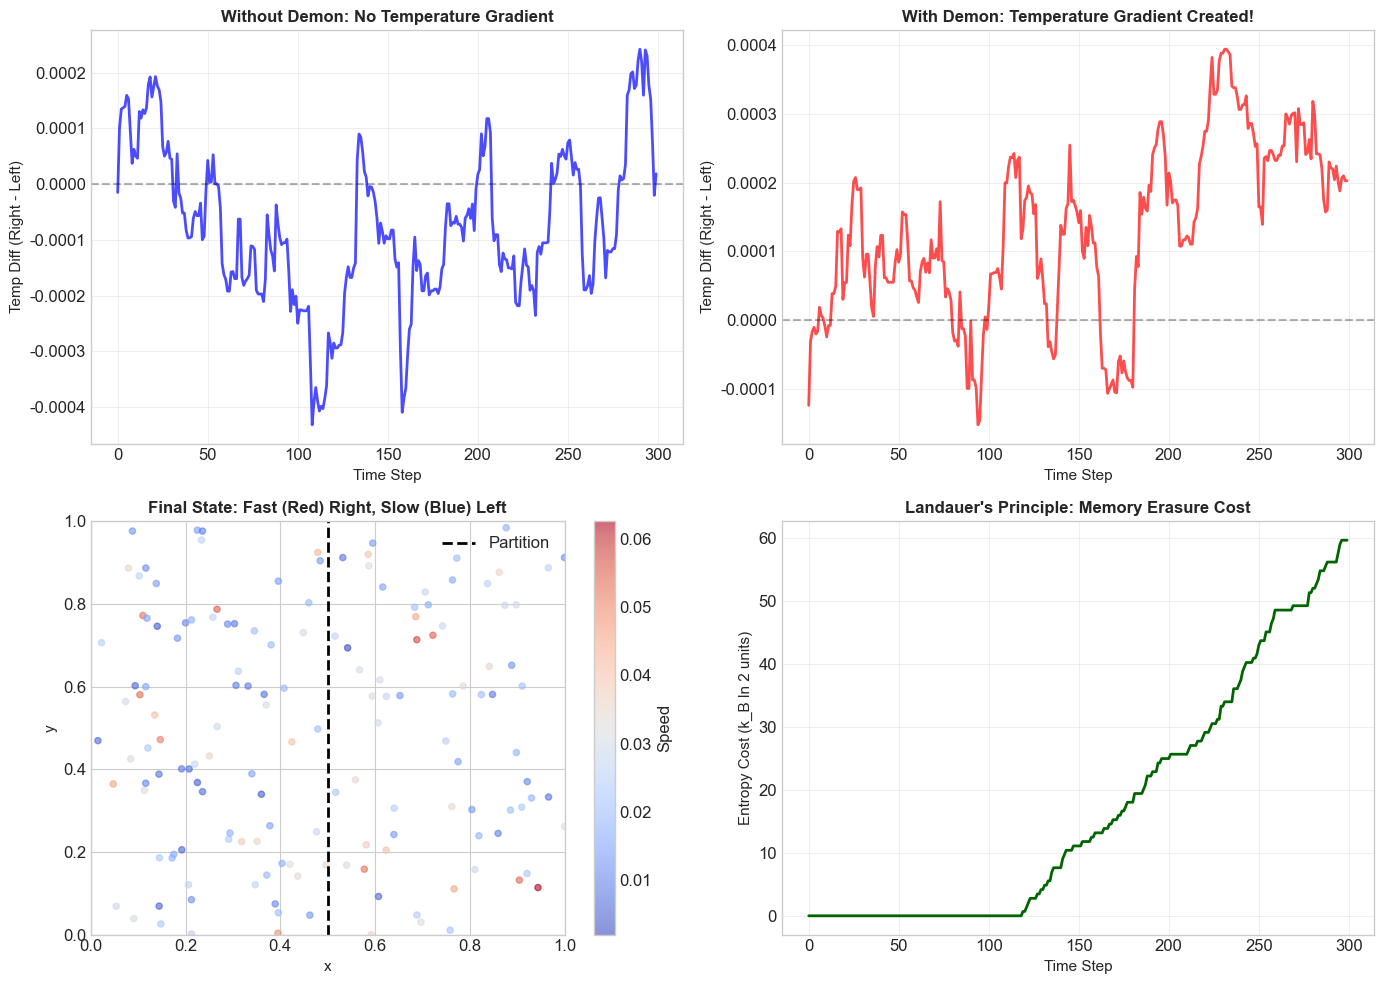


關鍵洞見：
  1. 妖精確實能創造溫度梯度（局部減少熵）
  2. 但妖精必須測量和記憶粒子速度
  3. 記憶體有限 → 必須擦除舊測量
  4. Landauer：擦除 1 bit ≥ k_B T ln(2) 熱量
  5. 擦除的熵成本: 59.61 k_B ln(2)
  6. 這恰好補償了妖精減少的熵！

→ 第二定律得救！資訊是物理的。


In [6]:
@dataclass
class GasParticle:
    """氣體粒子"""
    x: float
    y: float
    vx: float
    vy: float
    
    def speed(self) -> float:
        return np.sqrt(self.vx**2 + self.vy**2)


class MaxwellDemon:
    """Maxwell 妖精模擬器"""
    
    def __init__(self, num_particles: int = 100):
        self.num_particles = num_particles
        self.particles = self._initialize_particles()
        self.door_position = 0.5  # 中間隔板
        self.memory = []  # 妖精的記憶
        self.entropy_cost = 0.0  # 擦除成本
    
    def _initialize_particles(self) -> List[GasParticle]:
        """初始化 Maxwell-Boltzmann 分布的粒子"""
        particles = []
        for _ in range(self.num_particles):
            x = np.random.uniform(0.1, 0.9)
            y = np.random.uniform(0.1, 0.9)
            
            # Maxwell-Boltzmann 速度分布
            speed = np.random.rayleigh(0.02)
            angle = np.random.uniform(0, 2*np.pi)
            vx = speed * np.cos(angle)
            vy = speed * np.sin(angle)
            
            particles.append(GasParticle(x, y, vx, vy))
        return particles
    
    def update_without_demon(self, dt: float = 1.0):
        """沒有妖精的自然演化"""
        new_particles = []
        for p in self.particles:
            new_x = p.x + p.vx * dt
            new_y = p.y + p.vy * dt
            new_vx, new_vy = p.vx, p.vy
            
            if new_x < 0 or new_x > 1:
                new_vx = -new_vx
                new_x = np.clip(new_x, 0, 1)
            if new_y < 0 or new_y > 1:
                new_vy = -new_vy
                new_y = np.clip(new_y, 0, 1)
            
            new_particles.append(GasParticle(new_x, new_y, new_vx, new_vy))
        
        self.particles = new_particles
    
    def update_with_demon(self, dt: float = 1.0, threshold_speed: float = 0.025):
        """妖精操作門的演化"""
        new_particles = []
        
        for p in self.particles:
            new_x = p.x + p.vx * dt
            new_y = p.y + p.vy * dt
            new_vx, new_vy = p.vx, p.vy
            
            # 檢查是否穿過中間隔板
            crosses_door = ((p.x < self.door_position <= new_x) or 
                           (p.x > self.door_position >= new_x))
            
            if crosses_door and 0.4 < new_y < 0.6:  # 門在垂直中央
                # 妖精測量速度
                speed = p.speed()
                self.memory.append(speed)  # 儲存測量結果
                
                # 妖精規則：快粒子往右，慢粒子往左
                going_right = new_x > p.x
                is_fast = speed > threshold_speed
                
                if (going_right and not is_fast) or (not going_right and is_fast):
                    # 關門反射粒子
                    new_vx = -new_vx
                    new_x = p.x
            
            # 邊界反射
            if new_x < 0 or new_x > 1:
                new_vx = -new_vx
                new_x = np.clip(new_x, 0, 1)
            if new_y < 0 or new_y > 1:
                new_vy = -new_vy
                new_y = np.clip(new_y, 0, 1)
            
            new_particles.append(GasParticle(new_x, new_y, new_vx, new_vy))
        
        self.particles = new_particles
        
        # Landauer 擦除成本
        if len(self.memory) > 50:
            bits_erased = len(self.memory) - 50
            self.entropy_cost += bits_erased * np.log(2)  # k_B T ln(2) per bit
            self.memory = self.memory[-50:]
    
    def compute_temperature_difference(self) -> float:
        """計算左右兩邊的溫度差"""
        left = [p for p in self.particles if p.x < self.door_position]
        right = [p for p in self.particles if p.x >= self.door_position]
        
        if len(left) == 0 or len(right) == 0:
            return 0.0
        
        # 溫度 ∝ 平均動能 ∝ 平均速度²
        left_temp = np.mean([p.speed()**2 for p in left])
        right_temp = np.mean([p.speed()**2 for p in right])
        
        return right_temp - left_temp


# 模擬 Maxwell 妖精
print("模擬 Maxwell 妖精...")

# 沒有妖精
system_no_demon = MaxwellDemon(num_particles=150)
temp_diffs_no_demon = []

for _ in range(300):
    system_no_demon.update_without_demon()
    temp_diffs_no_demon.append(system_no_demon.compute_temperature_difference())

# 有妖精
system_with_demon = MaxwellDemon(num_particles=150)
temp_diffs_with_demon = []
entropy_costs = []

for _ in range(300):
    system_with_demon.update_with_demon()
    temp_diffs_with_demon.append(system_with_demon.compute_temperature_difference())
    entropy_costs.append(system_with_demon.entropy_cost)

# 視覺化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 圖 1：沒有妖精的溫度差
axes[0, 0].plot(temp_diffs_no_demon, linewidth=2, color='blue', alpha=0.7)
axes[0, 0].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[0, 0].set_xlabel('Time Step', fontsize=11)
axes[0, 0].set_ylabel('Temp Diff (Right - Left)', fontsize=11)
axes[0, 0].set_title('Without Demon: No Temperature Gradient', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 圖 2：有妖精的溫度差
axes[0, 1].plot(temp_diffs_with_demon, linewidth=2, color='red', alpha=0.7)
axes[0, 1].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[0, 1].set_xlabel('Time Step', fontsize=11)
axes[0, 1].set_ylabel('Temp Diff (Right - Left)', fontsize=11)
axes[0, 1].set_title('With Demon: Temperature Gradient Created!', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 圖 3：粒子分布（有妖精）
ax = axes[1, 0]
positions = np.array([[p.x, p.y] for p in system_with_demon.particles])
speeds = np.array([p.speed() for p in system_with_demon.particles])
scatter = ax.scatter(positions[:, 0], positions[:, 1],
                    c=speeds, s=20, cmap='coolwarm', alpha=0.6)
ax.axvline(0.5, color='black', linewidth=2, linestyle='--', label='Partition')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('x', fontsize=11)
ax.set_ylabel('y', fontsize=11)
ax.set_title('Final State: Fast (Red) Right, Slow (Blue) Left', fontsize=12, fontweight='bold')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Speed')

# 圖 4：Landauer 擦除成本
axes[1, 1].plot(entropy_costs, linewidth=2, color='darkgreen')
axes[1, 1].set_xlabel('Time Step', fontsize=11)
axes[1, 1].set_ylabel('Entropy Cost (k_B ln 2 units)', fontsize=11)
axes[1, 1].set_title("Landauer's Principle: Memory Erasure Cost", fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('maxwell_demon.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n關鍵洞見：")
print("  1. 妖精確實能創造溫度梯度（局部減少熵）")
print("  2. 但妖精必須測量和記憶粒子速度")
print("  3. 記憶體有限 → 必須擦除舊測量")
print(f"  4. Landauer：擦除 1 bit ≥ k_B T ln(2) 熱量")
print(f"  5. 擦除的熵成本: {entropy_costs[-1]:.2f} k_B ln(2)")
print("  6. 這恰好補償了妖精減少的熵！")
print("\n→ 第二定律得救！資訊是物理的。")

## 第六部分：計算不可逆性

**單向函數**：容易計算，難以反轉。

這與熱力學不可逆性類比：
- 雜湊 = 粗粒化
- 碰撞 = 多微觀態 → 同一巨觀態
- 資訊損失 = 熵增加

展示計算不可逆性...

範例 1：雜湊碰撞（多對一映射）
輸入數量: 1000
可能輸出: 64
平均每個輸出對應的輸入數: 15.6

碰撞範例: 輸入 [0, 64, 128, 192, 256] 都映射到 0

範例 2：密碼學雜湊（SHA-256）
訊息: 'Hello, World!'
SHA-256: dffd6021bb2bd5b0af676290809ec3a5...
訊息: 'Hello, World.'
SHA-256: 02b5dcd5f0ef1a39cffec5f8b625ec20...

注意：輸入只差一個字元，雜湊值完全不同（雪崩效應）！
這使得反轉計算上不可行。


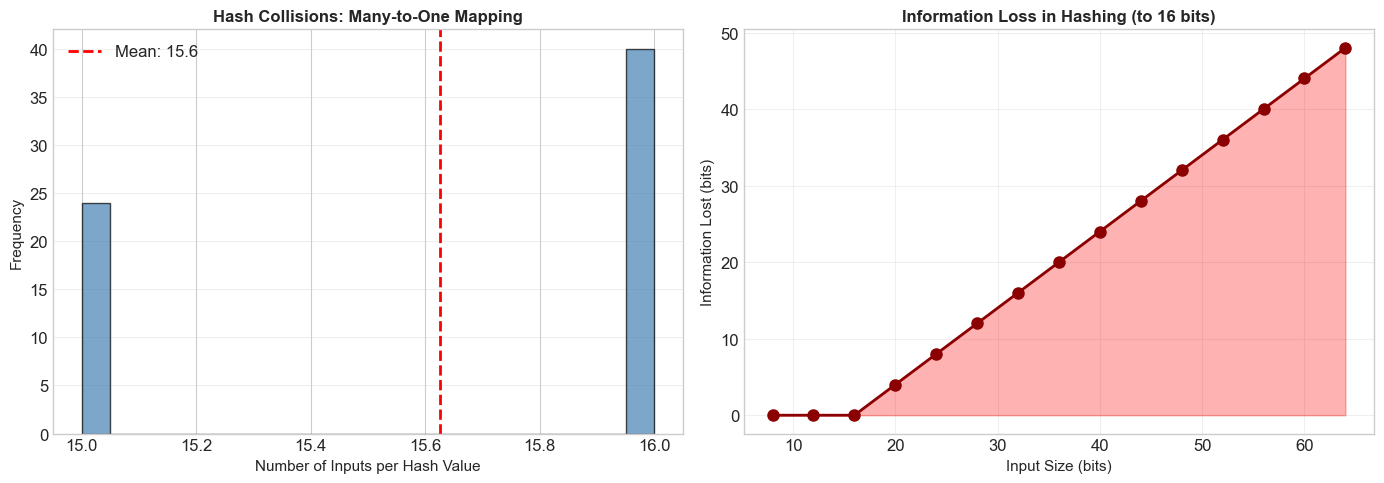


Landauer 原理與計算
雜湊 64-bit 輸入 → 16-bit 輸出:
  擦除的位元: 48
  最小能量成本: 1.38e-19 J
  (在 T=300K 時: 2.87e-21 J/bit)

現代 CPU: ~10⁻⁹ J/運算（遠高於 Landauer 極限）
Landauer 極限: 2.87e-21 J/bit
差距: ~10⁶ 倍，還有改進空間！


In [7]:
def simple_hash(x: int, num_bits_out: int = 8) -> int:
    """簡單雜湊函數（單向）"""
    return hash(x) % (2 ** num_bits_out)


def cryptographic_hash(data: str) -> str:
    """密碼學雜湊（SHA-256）"""
    return hashlib.sha256(data.encode()).hexdigest()


def demonstrate_collisions(num_inputs: int = 1000, num_bits_out: int = 6) -> Dict[int, List[int]]:
    """展示雜湊碰撞（多對一映射）"""
    hash_map = {}
    
    for x in range(num_inputs):
        h = simple_hash(x, num_bits_out)
        if h not in hash_map:
            hash_map[h] = []
        hash_map[h].append(x)
    
    return hash_map


# 展示計算不可逆性
print("展示計算不可逆性...\n")

# 雜湊碰撞
print("=" * 50)
print("範例 1：雜湊碰撞（多對一映射）")
print("=" * 50)

num_inputs = 1000
num_bits_out = 6  # 只有 64 種可能輸出
hash_map = demonstrate_collisions(num_inputs, num_bits_out)

print(f"輸入數量: {num_inputs}")
print(f"可能輸出: {2**num_bits_out}")
print(f"平均每個輸出對應的輸入數: {num_inputs / len(hash_map):.1f}")

# 展示碰撞範例
collision_example = [v for v in hash_map.values() if len(v) > 3][0]
print(f"\n碰撞範例: 輸入 {collision_example[:5]} 都映射到 {simple_hash(collision_example[0], num_bits_out)}")

# 密碼學雜湊
print("\n" + "=" * 50)
print("範例 2：密碼學雜湊（SHA-256）")
print("=" * 50)

messages = [
    "Hello, World!",
    "Hello, World.",  # 只差一個字元
]

for msg in messages:
    hash_val = cryptographic_hash(msg)
    print(f"訊息: '{msg}'")
    print(f"SHA-256: {hash_val[:32]}...")

print("\n注意：輸入只差一個字元，雜湊值完全不同（雪崩效應）！")
print("這使得反轉計算上不可行。")

# 視覺化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 圖 1：碰撞分布
ax = axes[0]
collision_counts = [len(v) for v in hash_map.values()]
ax.hist(collision_counts, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Number of Inputs per Hash Value', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Hash Collisions: Many-to-One Mapping', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.axvline(np.mean(collision_counts), color='red', linestyle='--', linewidth=2,
          label=f'Mean: {np.mean(collision_counts):.1f}')
ax.legend()

# 圖 2：資訊損失
ax = axes[1]
input_bits = np.arange(8, 65, 4)
output_bits = 16
info_loss = np.maximum(0, input_bits - output_bits)

ax.plot(input_bits, info_loss, 'o-', linewidth=2, markersize=8, color='darkred')
ax.fill_between(input_bits, 0, info_loss, alpha=0.3, color='red')
ax.set_xlabel('Input Size (bits)', fontsize=11)
ax.set_ylabel('Information Lost (bits)', fontsize=11)
ax.set_title(f'Information Loss in Hashing (to {output_bits} bits)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('computational_irreversibility.png', dpi=150, bbox_inches='tight')
plt.show()

# Landauer 成本
print("\n" + "=" * 50)
print("Landauer 原理與計算")
print("=" * 50)

bits_destroyed = 48  # 64-bit → 16-bit
k_B = 1.380649e-23  # Boltzmann 常數 (J/K)
T = 300  # 溫度 (K)
energy_per_bit = k_B * T * np.log(2)  # Joules
total_energy = bits_destroyed * energy_per_bit

print(f"雜湊 64-bit 輸入 → 16-bit 輸出:")
print(f"  擦除的位元: {bits_destroyed}")
print(f"  最小能量成本: {total_energy:.2e} J")
print(f"  (在 T=300K 時: {energy_per_bit:.2e} J/bit)")
print(f"\n現代 CPU: ~10⁻⁹ J/運算（遠高於 Landauer 極限）")
print(f"Landauer 極限: {energy_per_bit:.2e} J/bit")
print(f"差距: ~10⁶ 倍，還有改進空間！")

## 第七部分：資訊瓶頸與神經網路

**資訊瓶頸**：神經網路必須壓縮輸入，丟棄不相關細節。

$$\min_T [I(X; T) - \beta \cdot I(T; Y)]$$

這是計算版本的不可逆性——遺忘對泛化至關重要！

展示神經網路中的資訊瓶頸...

生成的資料:
  樣本數: 500
  輸入維度: 50
  真實潛在維度: 3
  壓縮比: 16.7×

自編碼器架構: 50 → 25 → 10 → 5 → 50
瓶頸: 5 維（壓縮比: 10.0×）

訓練自編碼器...
  Epoch 50: Loss = 0.3491
  Epoch 100: Loss = 0.2401
  Epoch 150: Loss = 0.2335
  Epoch 200: Loss = 0.2309


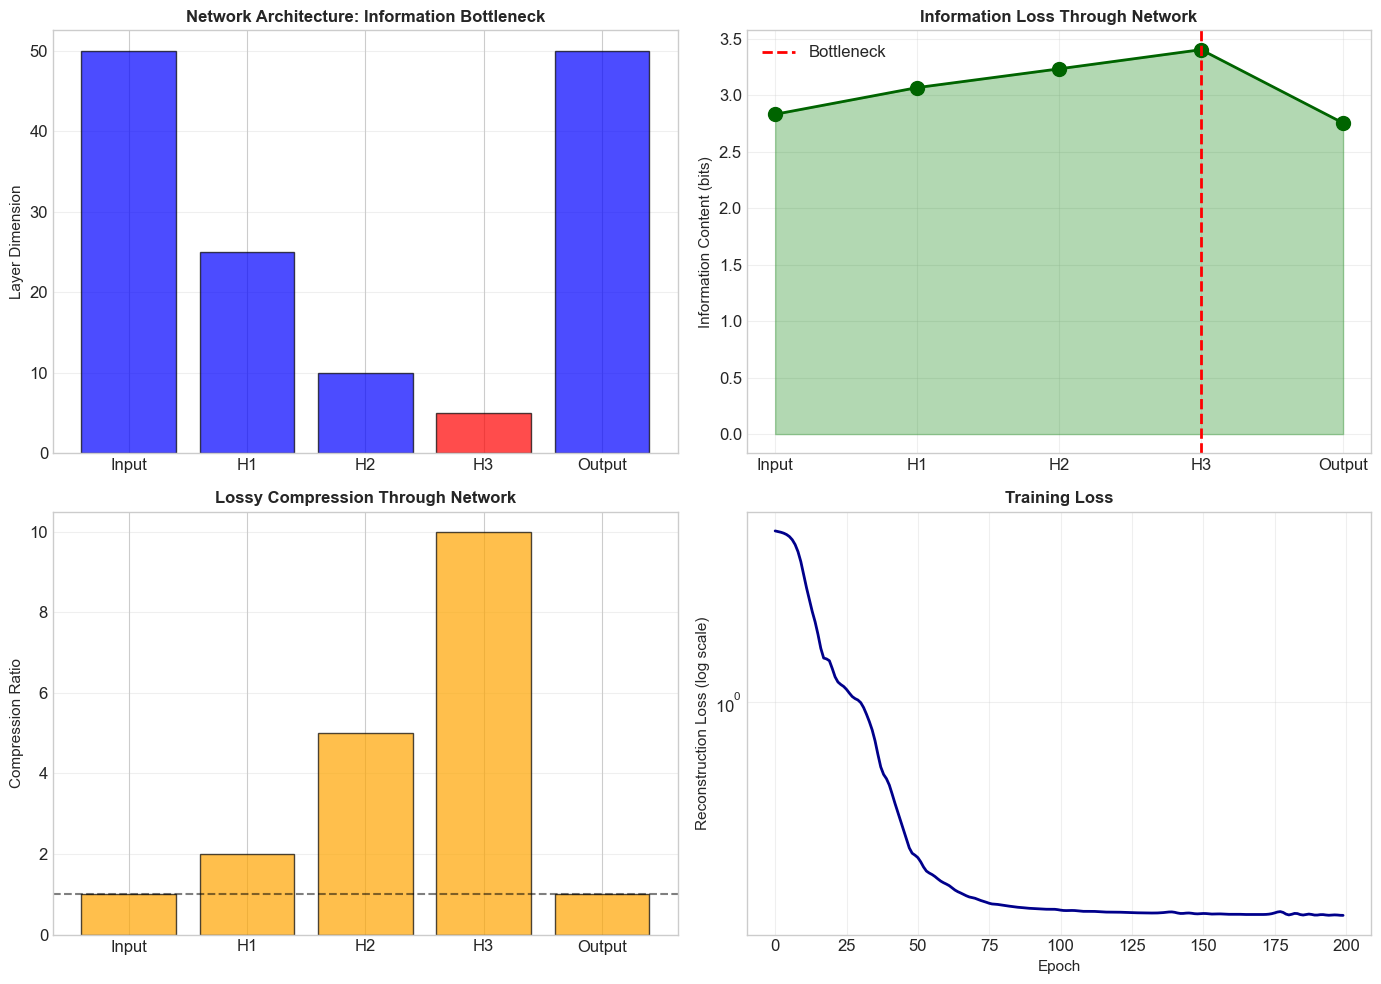


關鍵洞見：
  1. 輸入維度: 50，資訊: 2.83 bits
  2. 瓶頸維度: 5，資訊: 3.41 bits
  3. 損失的資訊: -0.57 bits (-20.2%)
  4. 這是故意的！網路遺忘噪音，記住結構。

→ 不可逆性（資訊損失）對學習至關重要！
→ 壓縮良好的網路泛化良好。


In [8]:
class InformationBottleneckNet(nn.Module):
    """
    展示資訊瓶頸的自編碼器
    
    架構：輸入 → 壓縮 → 瓶頸 → 解壓縮 → 輸出
    """
    
    def __init__(self, input_dim: int, hidden_dims: List[int]):
        super().__init__()
        
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        
        # 編碼器（壓縮）
        encoder_layers = []
        dims = [input_dim] + hidden_dims
        for i in range(len(dims) - 1):
            encoder_layers.append(nn.Linear(dims[i], dims[i+1]))
            encoder_layers.append(nn.ReLU())
        self.encoder = nn.Sequential(*encoder_layers[:-1])  # 移除最後的 ReLU
        
        # 解碼器（解壓縮）
        decoder_layers = []
        dims = hidden_dims[::-1] + [input_dim]
        for i in range(len(dims) - 1):
            decoder_layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                decoder_layers.append(nn.ReLU())
        self.decoder = nn.Sequential(*decoder_layers)
    
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)
    
    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)
    
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z


def estimate_entropy(activations: torch.Tensor, num_bins: int = 20) -> float:
    """估計活化值的熵"""
    flat = activations.detach().cpu().numpy().flatten()
    hist, _ = np.histogram(flat, bins=num_bins, density=True)
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist))


# 生成合成資料
print("展示神經網路中的資訊瓶頸...\n")

# 資料有低維潛在結構
num_samples = 500
input_dim = 50
latent_dim = 3  # 真正的潛在維度

# 生成資料：低維潛在 → 高維觀測
latent = np.random.randn(num_samples, latent_dim)
projection = np.random.randn(latent_dim, input_dim)
X = latent @ projection
X += np.random.randn(num_samples, input_dim) * 0.5  # 加噪音

X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

print(f"生成的資料:")
print(f"  樣本數: {num_samples}")
print(f"  輸入維度: {input_dim}")
print(f"  真實潛在維度: {latent_dim}")
print(f"  壓縮比: {input_dim/latent_dim:.1f}×")

# 建立自編碼器
hidden_dims = [25, 10, 5]  # 漸進壓縮
model = InformationBottleneckNet(input_dim, hidden_dims).to(device)

print(f"\n自編碼器架構: {input_dim} → {' → '.join(map(str, hidden_dims))} → {input_dim}")
print(f"瓶頸: {hidden_dims[-1]} 維（壓縮比: {input_dim/hidden_dims[-1]:.1f}×）")

# 訓練（簡單示範）
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

print("\n訓練自編碼器...")
losses = []
for epoch in range(200):
    optimizer.zero_grad()
    x_recon, z = model(X_tensor)
    loss = criterion(x_recon, X_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if (epoch + 1) % 50 == 0:
        print(f"  Epoch {epoch+1}: Loss = {loss.item():.4f}")

# 分析資訊流
model.eval()
with torch.no_grad():
    x_recon, z = model(X_tensor)
    
    # 獲取各層活化值
    layer_activations = [X_tensor]
    current = X_tensor
    for layer in model.encoder:
        current = layer(current)
        if isinstance(layer, nn.Linear):
            layer_activations.append(current)
    layer_activations.append(x_recon)

# 計算各層熵
layer_sizes = [input_dim] + hidden_dims + [input_dim]
layer_entropies = [estimate_entropy(act) for act in layer_activations]

# 視覺化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 圖 1：網路架構
ax = axes[0, 0]
x_pos = np.arange(len(layer_sizes))
colors = ['blue' if s > hidden_dims[-1] else 'red' for s in layer_sizes]
ax.bar(x_pos, layer_sizes, color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(['Input'] + [f'H{i+1}' for i in range(len(hidden_dims))] + ['Output'])
ax.set_ylabel('Layer Dimension', fontsize=11)
ax.set_title('Network Architecture: Information Bottleneck', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 圖 2：各層資訊含量
ax = axes[0, 1]
ax.plot(x_pos, layer_entropies, 'o-', linewidth=2, markersize=10, color='darkgreen')
ax.fill_between(x_pos, 0, layer_entropies, alpha=0.3, color='green')
ax.set_xticks(x_pos)
ax.set_xticklabels(['Input'] + [f'H{i+1}' for i in range(len(hidden_dims))] + ['Output'])
ax.set_ylabel('Information Content (bits)', fontsize=11)
ax.set_title('Information Loss Through Network', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axvline(len(hidden_dims), color='red', linestyle='--', linewidth=2, label='Bottleneck')
ax.legend()

# 圖 3：壓縮比
ax = axes[1, 0]
compression_ratios = [layer_sizes[0] / s for s in layer_sizes]
ax.bar(x_pos, compression_ratios, color='orange', alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(['Input'] + [f'H{i+1}' for i in range(len(hidden_dims))] + ['Output'])
ax.set_ylabel('Compression Ratio', fontsize=11)
ax.set_title('Lossy Compression Through Network', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(1, color='black', linestyle='--', alpha=0.5)

# 圖 4：訓練損失
ax = axes[1, 1]
ax.semilogy(losses, linewidth=2, color='darkblue')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Reconstruction Loss (log scale)', fontsize=11)
ax.set_title('Training Loss', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('information_bottleneck.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n關鍵洞見：")
print(f"  1. 輸入維度: {input_dim}，資訊: {layer_entropies[0]:.2f} bits")
print(f"  2. 瓶頸維度: {hidden_dims[-1]}，資訊: {layer_entropies[len(hidden_dims)]:.2f} bits")
info_lost = layer_entropies[0] - layer_entropies[len(hidden_dims)]
print(f"  3. 損失的資訊: {info_lost:.2f} bits ({info_lost/layer_entropies[0]*100:.1f}%)")
print("  4. 這是故意的！網路遺忘噪音，記住結構。")
print("\n→ 不可逆性（資訊損失）對學習至關重要！")
print("→ 壓縮良好的網路泛化良好。")

## 第八部分：時間箭頭

三種時間箭頭：
1. **熱力學箭頭**：熵增加
2. **心理學箭頭**：記得過去，不記得未來
3. **宇宙學箭頭**：宇宙膨脹

所有三者都源於同一事實：**大爆炸具有極低的熵**。

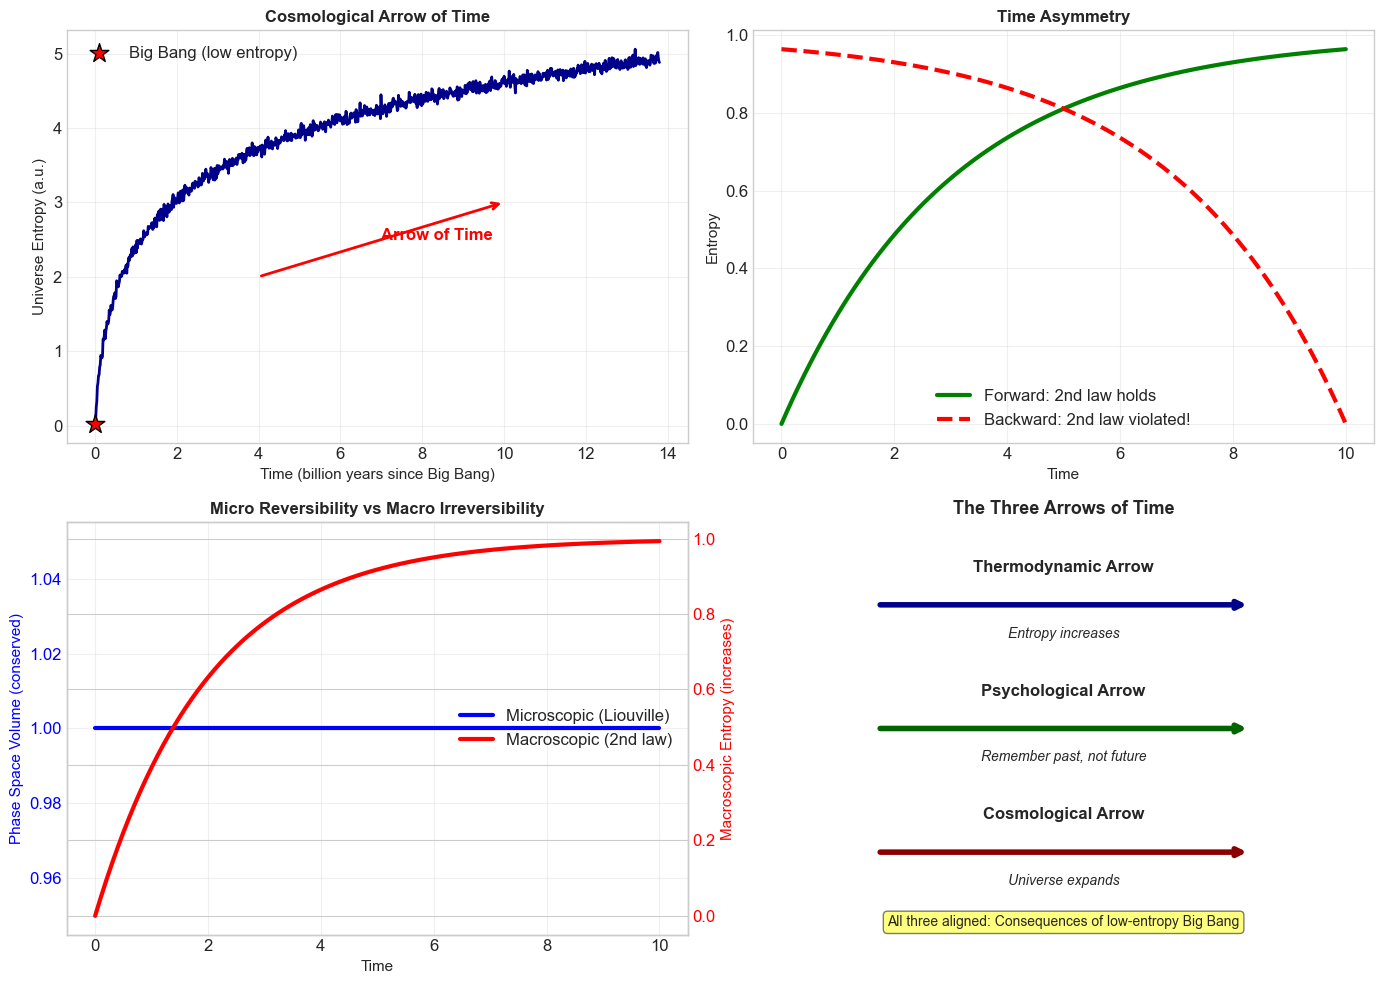


時間的深層洞見：

1. 微觀定律：時間可逆（牛頓、量子力學）
   → 反向運行定律在數學上完全有效

2. 巨觀行為：時間不可逆（熱力學）
   → 熵增加，混合發生，無法逆轉

3. 解答：初始條件 + 統計
   → 大爆炸具有極低的熵
   → 統計演化探索高熵狀態
   → 粗粒化使演化看起來不可逆

4. 深層謎題：為什麼大爆炸是低熵的？
   → 我們不知道！這是時間箭頭的來源。


In [9]:
# 視覺化時間箭頭
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 圖 1：宇宙熵隨時間變化
ax = axes[0, 0]
time_universe = np.linspace(0, 13.8, 1000)  # 十億年
entropy_universe = np.log(1 + time_universe * 10) + np.random.randn(1000) * 0.05

ax.plot(time_universe, entropy_universe, linewidth=2, color='darkblue')
ax.scatter([0], [entropy_universe[0]], s=200, c='red', marker='*',
          label='Big Bang (low entropy)', zorder=5, edgecolor='black')
ax.annotate('Arrow of Time', xy=(7, 2.5), fontsize=12, color='red', fontweight='bold')
ax.annotate('', xy=(10, 3), xytext=(4, 2),
           arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.set_xlabel('Time (billion years since Big Bang)', fontsize=11)
ax.set_ylabel('Universe Entropy (a.u.)', fontsize=11)
ax.set_title('Cosmological Arrow of Time', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 圖 2：正向 vs 反向時間
ax = axes[0, 1]
t = np.linspace(0, 10, 100)
entropy_forward = 1 - np.exp(-t/3)
entropy_backward = np.flip(entropy_forward)

ax.plot(t, entropy_forward, linewidth=3, color='green', label='Forward: 2nd law holds')
ax.plot(t, entropy_backward, linewidth=3, color='red', linestyle='--',
       label='Backward: 2nd law violated!')
ax.set_xlabel('Time', fontsize=11)
ax.set_ylabel('Entropy', fontsize=11)
ax.set_title('Time Asymmetry', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 圖 3：微觀 vs 巨觀
ax = axes[1, 0]
t = np.linspace(0, 10, 100)
phase_volume = np.ones_like(t)  # Liouville：常數
macro_entropy = 1 - np.exp(-t/2)  # 增加

ax2 = ax.twinx()
line1, = ax.plot(t, phase_volume, linewidth=3, color='blue', label='Microscopic (Liouville)')
line2, = ax2.plot(t, macro_entropy, linewidth=3, color='red', label='Macroscopic (2nd law)')
ax.set_xlabel('Time', fontsize=11)
ax.set_ylabel('Phase Space Volume (conserved)', fontsize=11, color='blue')
ax2.set_ylabel('Macroscopic Entropy (increases)', fontsize=11, color='red')
ax.set_title('Micro Reversibility vs Macro Irreversibility', fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
ax.legend([line1, line2], ['Microscopic (Liouville)', 'Macroscopic (2nd law)'], loc='center right')
ax.grid(True, alpha=0.3)

# 圖 4：三個箭頭
ax = axes[1, 1]
ax.axis('off')

arrows_info = [
    (0.8, 'Thermodynamic Arrow', 'Entropy increases', 'darkblue'),
    (0.5, 'Psychological Arrow', 'Remember past, not future', 'darkgreen'),
    (0.2, 'Cosmological Arrow', 'Universe expands', 'darkred'),
]

for y, title, desc, color in arrows_info:
    ax.annotate('', xy=(0.8, y), xytext=(0.2, y),
               arrowprops=dict(arrowstyle='->', lw=4, color=color))
    ax.text(0.5, y + 0.08, title, ha='center', fontsize=12, fontweight='bold')
    ax.text(0.5, y - 0.08, desc, ha='center', fontsize=10, style='italic')

ax.text(0.5, 0.02, 'All three aligned: Consequences of low-entropy Big Bang',
       ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('The Three Arrows of Time', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('arrow_of_time.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n時間的深層洞見：")
print("\n1. 微觀定律：時間可逆（牛頓、量子力學）")
print("   → 反向運行定律在數學上完全有效")
print("\n2. 巨觀行為：時間不可逆（熱力學）")
print("   → 熵增加，混合發生，無法逆轉")
print("\n3. 解答：初始條件 + 統計")
print("   → 大爆炸具有極低的熵")
print("   → 統計演化探索高熵狀態")
print("   → 粗粒化使演化看起來不可逆")
print("\n4. 深層謎題：為什麼大爆炸是低熵的？")
print("   → 我們不知道！這是時間箭頭的來源。")

## 第九部分：生命與熱力學

生命是**開放系統**：
- 輸入低熵能量（食物、陽光）
- 維持自身有序結構
- 輸出高熵廢物（熱、CO₂）

局部熵可以降低，但**總熵仍然增加**！

模擬開放系統（類似生命）vs 封閉系統...


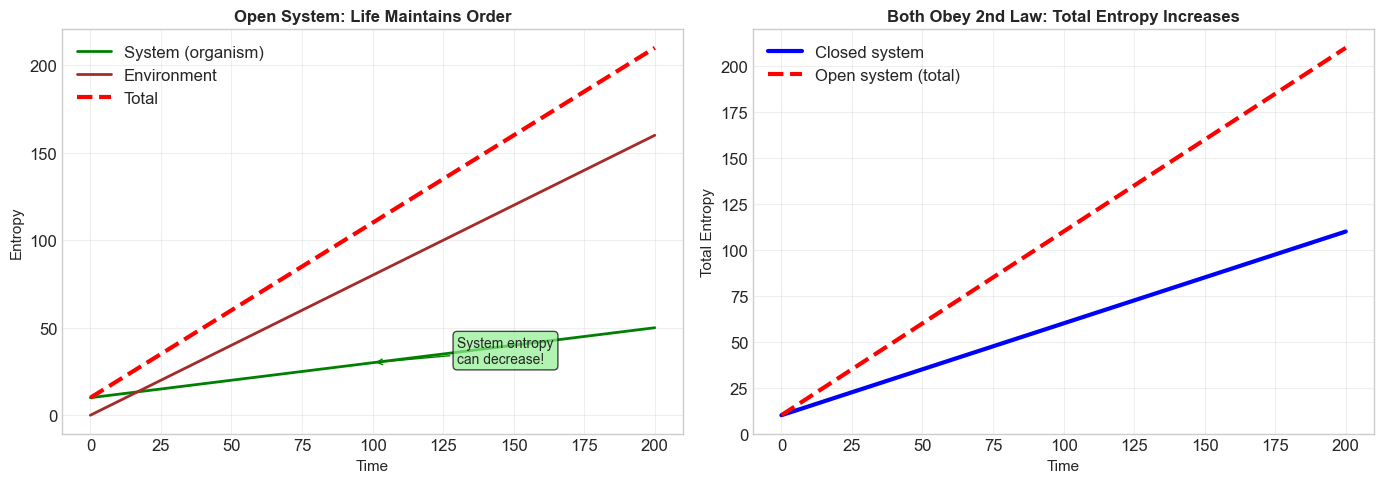


生命與熵的關鍵洞見：

1. 局部 vs 全域：
   → 系統熵: 10.0 → 50.0（維持低！）
   → 總熵: 10.0 → 210.0（增加！）

2. 生命的訣竅：
   → 輸入低熵能量（食物、陽光）
   → 建立有序結構（蛋白質、細胞、生物體）
   → 輸出高熵廢物（熱、CO₂ 等）

3. 淨結果：
   → 生物體熵 ↓（更有序）
   → 環境熵 ↑↑（更多無序）
   → 總熵 ↑（第二定律滿足！）

4. Schrödinger 說對了：
   → 生命以負熵為食
   → 這就是生命如何與第二定律相容！


In [10]:
def simulate_open_system(num_steps: int = 200) -> Dict[str, List[float]]:
    """模擬維持低熵的開放系統（類似生命）"""
    S_system = 10.0  # 系統初始熵
    S_environment = 0.0  # 輸出到環境的熵
    
    history = {
        'system': [S_system],
        'environment': [S_environment],
        'total': [S_system + S_environment]
    }
    
    for _ in range(num_steps):
        # 自然熵增加
        natural_increase = 0.5
        
        # 主動維持：系統輸出熵到環境
        # 這「花費」更多環境熵（第二定律）
        entropy_exported = 0.8
        entropy_reduced = 0.3
        
        S_system = S_system + natural_increase - entropy_reduced
        S_environment = S_environment + entropy_exported
        
        history['system'].append(S_system)
        history['environment'].append(S_environment)
        history['total'].append(S_system + S_environment)
    
    return history


def simulate_closed_system(num_steps: int = 200) -> Dict[str, List[float]]:
    """模擬封閉系統（作為對比）"""
    S_total = 10.0
    history = {'total': [S_total]}
    
    for _ in range(num_steps):
        S_total = S_total + 0.5
        history['total'].append(S_total)
    
    return history


# 模擬
print("模擬開放系統（類似生命）vs 封閉系統...")

open_sys = simulate_open_system()
closed_sys = simulate_closed_system()

# 視覺化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 圖 1：開放系統
ax = axes[0]
t = np.arange(len(open_sys['total']))
ax.plot(t, open_sys['system'], linewidth=2, label='System (organism)', color='green')
ax.plot(t, open_sys['environment'], linewidth=2, label='Environment', color='brown')
ax.plot(t, open_sys['total'], linewidth=3, label='Total', color='red', linestyle='--')
ax.set_xlabel('Time', fontsize=11)
ax.set_ylabel('Entropy', fontsize=11)
ax.set_title('Open System: Life Maintains Order', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 添加註解
ax.annotate('System entropy\ncan decrease!', xy=(100, open_sys['system'][100]),
           xytext=(130, 30), fontsize=10,
           bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7),
           arrowprops=dict(arrowstyle='->', color='green'))

# 圖 2：與封閉系統比較
ax = axes[1]
ax.plot(t, closed_sys['total'], linewidth=3, label='Closed system', color='blue')
ax.plot(t, open_sys['total'], linewidth=3, label='Open system (total)', color='red', linestyle='--')
ax.set_xlabel('Time', fontsize=11)
ax.set_ylabel('Total Entropy', fontsize=11)
ax.set_title('Both Obey 2nd Law: Total Entropy Increases', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('life_thermodynamics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n生命與熵的關鍵洞見：")
print(f"\n1. 局部 vs 全域：")
print(f"   → 系統熵: {open_sys['system'][0]:.1f} → {open_sys['system'][-1]:.1f}（維持低！）")
print(f"   → 總熵: {open_sys['total'][0]:.1f} → {open_sys['total'][-1]:.1f}（增加！）")
print("\n2. 生命的訣竅：")
print("   → 輸入低熵能量（食物、陽光）")
print("   → 建立有序結構（蛋白質、細胞、生物體）")
print("   → 輸出高熵廢物（熱、CO₂ 等）")
print("\n3. 淨結果：")
print("   → 生物體熵 ↓（更有序）")
print("   → 環境熵 ↑↑（更多無序）")
print("   → 總熵 ↑（第二定律滿足！）")
print("\n4. Schrödinger 說對了：")
print("   → 生命以負熵為食")
print("   → 這就是生命如何與第二定律相容！")

## 總結：不可逆性的統一視角

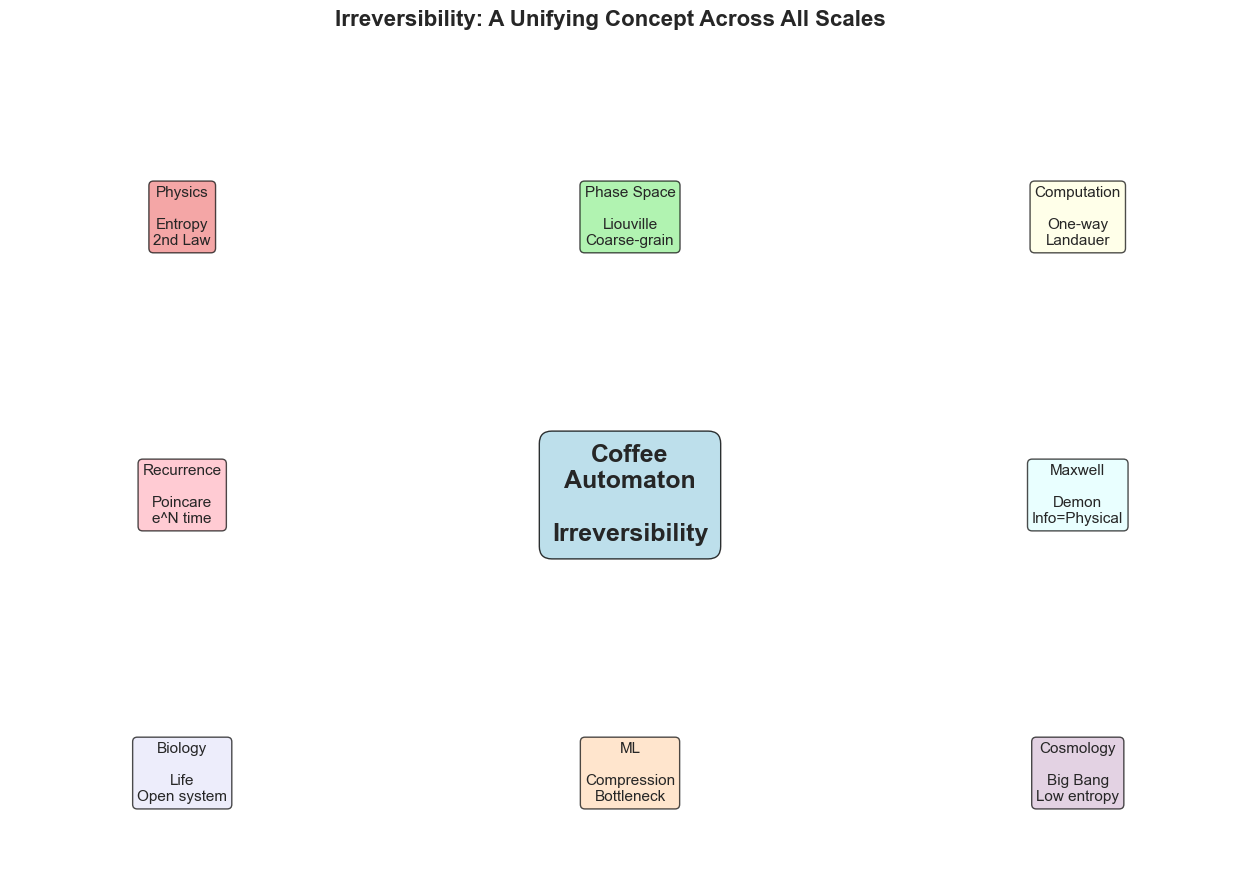


總結：咖啡自動機的核心教訓

1. 微觀可逆，巨觀不可逆
   • 基本定律是時間對稱的
   • 但統計和粗粒化產生時間箭頭

2. 熵增加的統計本質
   • 高熵狀態在統計上壓倒性地更可能
   • 這不是定律，是數學

3. Poincaré 回歸的實際無關性
   • 系統確實會返回初始狀態
   • 但時間尺度是 e^N，遠超宇宙年齡

4. 資訊是物理的
   • Landauer：擦除資訊有能量成本
   • 解決了 Maxwell 妖精悖論

5. 計算不可逆性
   • 單向函數是計算版本的熵增加
   • 對密碼學和安全至關重要

6. 機器學習與資訊瓶頸
   • 神經網路必須「遺忘」才能泛化
   • 不可逆壓縮是學習的核心

7. 時間箭頭的統一來源
   • 三種箭頭都源於大爆炸的低熵初始條件
   • 這仍是物理學最深刻的未解之謎

咖啡自動機教會我們：
   你無法讓混合的咖啡分離。
   但正是這種不可逆性，
   使得計算、生命和思想成為可能。

第十九章實作完成！


In [11]:
# 最終視覺化：完整圖景
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 中央概念
ax_center = fig.add_subplot(gs[1, 1])
ax_center.axis('off')
ax_center.text(0.5, 0.5, 'Coffee\nAutomaton\n\nIrreversibility',
              ha='center', va='center', fontsize=18, fontweight='bold',
              bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
ax_center.set_xlim(0, 1)
ax_center.set_ylim(0, 1)

# 周圍概念
concepts = [
    ("Physics\n\nEntropy\n2nd Law", gs[0, 0], 'lightcoral'),
    ("Phase Space\n\nLiouville\nCoarse-grain", gs[0, 1], 'lightgreen'),
    ("Computation\n\nOne-way\nLandauer", gs[0, 2], 'lightyellow'),
    ("Recurrence\n\nPoincare\ne^N time", gs[1, 0], 'lightpink'),
    ("Maxwell\n\nDemon\nInfo=Physical", gs[1, 2], 'lightcyan'),
    ("Biology\n\nLife\nOpen system", gs[2, 0], 'lavender'),
    ("ML\n\nCompression\nBottleneck", gs[2, 1], 'peachpuff'),
    ("Cosmology\n\nBig Bang\nLow entropy", gs[2, 2], 'thistle'),
]

for text, pos, color in concepts:
    ax = fig.add_subplot(pos)
    ax.axis('off')
    ax.text(0.5, 0.5, text, ha='center', va='center', fontsize=11,
           bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle('Irreversibility: A Unifying Concept Across All Scales',
            fontsize=16, fontweight='bold', y=0.98)
plt.savefig('synthesis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("總結：咖啡自動機的核心教訓")
print("=" * 70)

print("""
1. 微觀可逆，巨觀不可逆
   • 基本定律是時間對稱的
   • 但統計和粗粒化產生時間箭頭

2. 熵增加的統計本質
   • 高熵狀態在統計上壓倒性地更可能
   • 這不是定律，是數學

3. Poincaré 回歸的實際無關性
   • 系統確實會返回初始狀態
   • 但時間尺度是 e^N，遠超宇宙年齡

4. 資訊是物理的
   • Landauer：擦除資訊有能量成本
   • 解決了 Maxwell 妖精悖論

5. 計算不可逆性
   • 單向函數是計算版本的熵增加
   • 對密碼學和安全至關重要

6. 機器學習與資訊瓶頸
   • 神經網路必須「遺忘」才能泛化
   • 不可逆壓縮是學習的核心

7. 時間箭頭的統一來源
   • 三種箭頭都源於大爆炸的低熵初始條件
   • 這仍是物理學最深刻的未解之謎

咖啡自動機教會我們：
   你無法讓混合的咖啡分離。
   但正是這種不可逆性，
   使得計算、生命和思想成為可能。
""")

print("=" * 70)
print("第十九章實作完成！")
print("=" * 70)